# Applied Machine Learning Experiment: Multiple Linear Regression

**Author:** Dorsa Norouzi  
**Project Type:** Portfolio Demo / Machine Learning Practice  
**Year:** 2026

## Project Overview

This notebook extends linear regression to a housing-price prediction problem with multiple input features. The workflow includes feature normalization, gradient descent, learning-rate comparison, prediction, the normal equation, and a comparison with scikit-learn.

## What This Notebook Demonstrates

- Multiple-feature linear regression
- Feature scaling / standardization
- Vectorized cost and gradient computation
- Gradient descent with different learning rates
- Prediction for new housing examples
- Closed-form regression using the normal equation
- Comparison with scikit-learn preprocessing and regression


In [34]:
%matplotlib notebook
%matplotlib inline
import numpy as np

filename = "datasets/housing-dataset.csv"
mydata = np.genfromtxt(filename, delimiter=",")

# We have n data-points (houses)
n = len(mydata)

# X is a matrix of two column, i.e. an array of n 2-dimensional data-points
X = mydata[:, :2].reshape(n, 2)

# y is the vector of outputs, i.e. an array of n scalar values
y = mydata[:, -1]



print(X[:10])
print(y[:5])


[[2.104e+03 3.000e+00]
 [1.600e+03 3.000e+00]
 [2.400e+03 3.000e+00]
 [1.416e+03 2.000e+00]
 [3.000e+03 4.000e+00]
 [1.985e+03 4.000e+00]
 [1.534e+03 3.000e+00]
 [1.427e+03 3.000e+00]
 [1.380e+03 3.000e+00]
 [1.494e+03 3.000e+00]]
[399900. 329900. 369000. 232000. 539900.]


## 1. Feature Scaling

The housing dataset contains features on different numeric scales, such as house size and number of bedrooms. Standardization is applied before gradient descent so the optimization process can converge more smoothly.


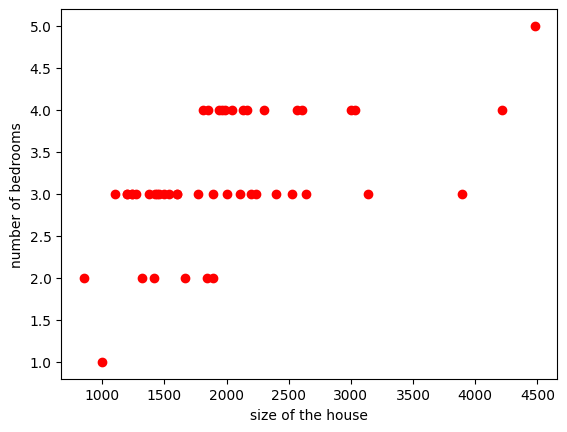

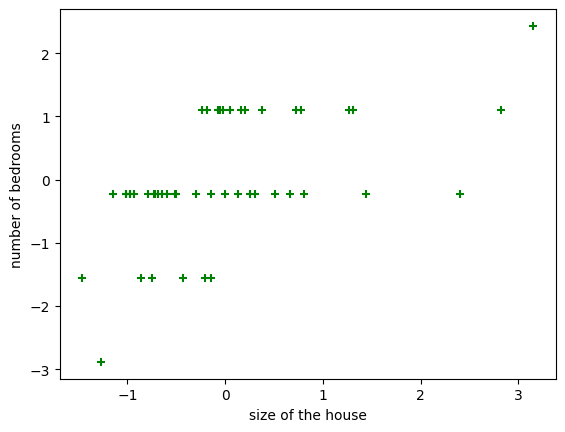

In [35]:
import matplotlib.pylab as plt


mu = np.mean(X, axis=0)

std = np.std(X, axis=0)
X_normalized = (X - mu) / std




fig, ax = plt.subplots()
ax.scatter(X[:,0],X[:,1],color = "red",marker = "o")
ax.set_xlabel("size of the house")
ax.set_ylabel("number of bedrooms")
plt.show()


fig, ax = plt.subplots()
ax.scatter(X_normalized[:,0],X_normalized[:,1],color = "green",marker = "+")
ax.set_xlabel("size of the house")
ax.set_ylabel("number of bedrooms")
plt.show()


## 2. Adding the Intercept Term

A column of ones is added to the normalized feature matrix so the regression model can learn an intercept parameter.


In [36]:
# definition of the function add_all_ones_column() here
def add_all_ones_column(X):
    n, d = X.shape # dimension of the matrix X (n lines, d columns)
    XX = np.ones((n, d+1)) # new matrix of all ones with one additional column
    XX[:, 1:] = X # set X starting from column 1 (keep only column 0 unchanged)
    return XX


X_normalized_new = add_all_ones_column(X_normalized)

print("Subset of X_normalized_new")
print(X_normalized_new[:10])


Subset of X_normalized_new
[[ 1.          0.13141542 -0.22609337]
 [ 1.         -0.5096407  -0.22609337]
 [ 1.          0.5079087  -0.22609337]
 [ 1.         -0.74367706 -1.5543919 ]
 [ 1.          1.27107075  1.10220517]
 [ 1.         -0.01994505  1.10220517]
 [ 1.         -0.59358852 -0.22609337]
 [ 1.         -0.72968575 -0.22609337]
 [ 1.         -0.78946678 -0.22609337]
 [ 1.         -0.64446599 -0.22609337]]


## 3. Multiple Linear Regression with Gradient Descent

The cost function and gradient are implemented in vectorized form, and gradient descent is used to learn the regression parameters for multiple input features.


alpha = 0.01, theta = [215810.61679138  61446.18781361  20070.13313796]
alpha = 0.05, theta = [ 3.38397236e+05  1.03161481e+05 -3.22620198e+02]
alpha = 0.1, theta = [340403.61773803 108803.37852266  -5933.9413402 ]


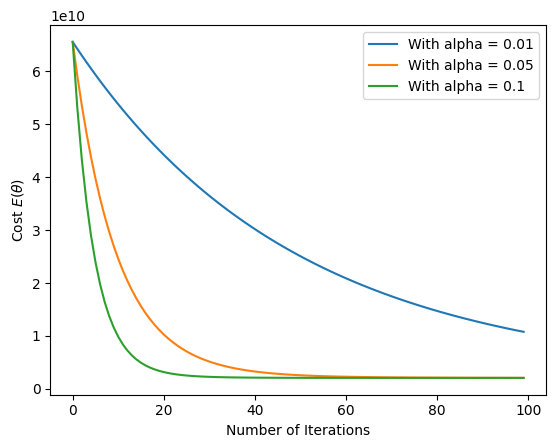

In [37]:
def E(theta, X, y):
    n = len(y)
    return (1/(2*n)) * (((X @ theta)-y).T)@((X @ theta)-y)


def grad_E(theta, X, y):
    n = len(y)
    return (1/n) * (X.T @ (X @ theta - y))


def LinearRegressionWithGD(theta, alpha, max_iterations, epsilon):
    errs = []
    prev = []
    for itr in range(max_iterations):
        mse = E(theta, X_normalized_new, y)
        errs.append(mse)

        gd =  grad_E(theta, X_normalized_new, y)
        theta = theta - alpha * gd
        CONDITION = abs(prev - mse) < epsilon
        if CONDITION:
            break

        prev = mse
    return errs, theta



fig, ax = plt.subplots()
ax.set_xlabel("Number of Iterations")
ax.set_ylabel(r"Cost $E(\theta)$")

theta_init = np.array([0, 0, 0])
max_iterations = 100
epsilon = 0.000000000001

for alpha in [0.01, 0.05, 0.1]:

    errs , theta = LinearRegressionWithGD(theta_init.copy(), alpha, max_iterations, epsilon)

    # print("alpha = {}, theta = {}".format(alpha, theta))
    print(f"alpha = {alpha}, theta = {theta}")

    # plot the errs using ax.plot(..)
    ax.plot(range(len(errs)), errs , label = f"With alpha = {alpha}" )

plt.legend()
plt.show()


## 4. Housing Price Prediction

After training, the model predicts the price of a 1650-square-foot house with 3 bedrooms. The input is normalized using the same statistics as the training data.


In [ ]:
# Creating a data-point x corresponding to the new house
X_pred = np.array([[1650,3]])
theta = theta.reshape(-1,1)

# Normalizing the feature values of x
X_pred_normalized = (X_pred - mu) / std
X_pred_normalized_new = add_all_ones_column(X_pred_normalized)

# Using the vector of parameters theta to predict the price of x
prediction1 = np.dot( X_pred_normalized_new ,theta)

print(f"The predicted price is:{prediction1}")


The predicted price is:[[293214.16354571]]


## 5. Normal Equation Preparation

This section moves from iterative optimization to the closed-form normal equation solution.


## 6. Normal Equation

The normal equation computes the optimal regression parameters directly without gradient descent. Unlike gradient descent, this method does not require iterative updates.

$$\theta = (X^T X)^{-1}X^T y$$


In [45]:
from numpy.linalg import inv


X_new = add_all_ones_column(X)


theta = inv(X_new.T @ X_new) @ X_new.T@ y
print("With the original (non-normalized) dataset: theta = {}".format(theta))


With the original (non-normalized) dataset: theta = [89597.9095428    139.21067402 -8738.01911233]


## 7. Prediction with the Normal Equation

The normal-equation parameters are used to predict the same housing example, allowing comparison with the gradient-descent result.


In [68]:
x = np.array([[1,1650,3]])
prediction = np.dot(x,theta)
print(f"The predicted price is:{prediction[0]:.2f}")


The predicted price is:293081.46


## 8. Normal Equation with Normalized Features

The normal equation is also applied to the normalized feature matrix to compare parameter behavior across scaled and unscaled inputs.


In [48]:
from numpy.linalg import inv
print(X_normalized_new[:5])
theta = inv(X_normalized_new.T @ X_normalized_new) @ X_normalized_new.T@ y

print("With the original (normalized) dataset: theta = {}".format(theta))


[[ 1.          0.13141542 -0.22609337]
 [ 1.         -0.5096407  -0.22609337]
 [ 1.          0.5079087  -0.22609337]
 [ 1.         -0.74367706 -1.5543919 ]
 [ 1.          1.27107075  1.10220517]]
With the original (normalized) dataset: theta = [340412.65957447 109447.79646964  -6578.35485416]


## 9. Prediction with Normalized Normal-Equation Parameters

The new housing example is normalized and predicted again using the parameters learned from the normalized feature matrix.


In [50]:
# Create a data-point x corresponding to the new house
X_pred = np.array([1650,3])
# Normalize the feature values of x
X_pred_normalized = (X_pred - mu)/std
X_pred_normalized = X_pred_normalized.reshape(1, -1)
X_pred_normalized_new = add_all_ones_column(X_pred_normalized)
# Use the vector of parameters theta to predict the price of x
pred = np.dot(X_pred_normalized_new,theta)
print("prediction:", pred)


prediction: [293081.4643349]


## 10. scikit-learn Preprocessing and Regression

The scikit-learn workflow uses `StandardScaler` for feature scaling and `LinearRegression` for model fitting.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Fit the StandardScaler to the training data (to compute the mean and std-deviation)
scaler = StandardScaler().fit(X)

# We use scaler to transform (scale) the training data or any new test data
X_normalized = scaler.transform(X)

print("Original X:\n", X[:5])
print()
print("X_normalized:\n", X_normalized[:5])


Original X:
 [[2.104e+03 3.000e+00]
 [1.600e+03 3.000e+00]
 [2.400e+03 3.000e+00]
 [1.416e+03 2.000e+00]
 [3.000e+03 4.000e+00]]

X_normalized:
 [[ 0.13141542 -0.22609337]
 [-0.5096407  -0.22609337]
 [ 0.5079087  -0.22609337]
 [-0.74367706 -1.5543919 ]
 [ 1.27107075  1.10220517]]


## 11. Model Training with scikit-learn

The scikit-learn model is trained on the scaled features.


In [52]:
from sklearn.linear_model import LinearRegression


reg = LinearRegression().fit(X_normalized, y)


In [53]:
# X_test = ... # Create the test dataset
X_test = np.array([[1650,3],[1020,2],[2300,4]])
# Scale the test dataset using scaler.transform(...)
X_test_normalized = scaler.transform(X_test)
X_test_normalized_new = add_all_ones_column(X_test_normalized)
# Predict the prices using reg.predict(...)

prediction = np.dot( X_test_normalized_new ,theta)
print(f"The predicted prices are:{prediction}")


The predicted prices are:[293081.4643349  214116.75881612 374830.38333402]


## 12. Summary

This experiment demonstrates a complete multiple linear regression workflow, including scaling, gradient descent, the normal equation, and scikit-learn comparison.
